In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving complaints.csv to complaints (2).csv


In [ ]:
df = pd.read_csv("complaints.csv")

In [ ]:
# First five rows
df.head()
# Last five rows
df.tail()
# Shape of the dataset
df.shape
# Column names
df.columns
# Dataset information
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126974 entries, 0 to 126973
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Complaint ID      126974 non-null  int64 
 1   Category          126974 non-null  object
 2   Sub Category      126974 non-null  object
 3   Grievance Date    126974 non-null  object
 4   Ward Name         126974 non-null  object
 5   Grievance Status  126920 non-null  object
 6   Staff Remarks     126920 non-null  object
 7   Staff Name        126920 non-null  object
dtypes: int64(1), object(7)
memory usage: 7.8+ MB


In [ ]:
df.isnull().sum()

,0
Complaint ID,0
Category,0
Sub Category,0
Grievance Date,0
Ward Name,0
Grievance Status,54
Staff Remarks,54
Staff Name,54


In [ ]:
# Calculate missing values and percentages
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df)) * 100
})

missing

,Missing Values,Percentage
Complaint ID,0,0.000000
Category,0,0.000000
Sub Category,0,0.000000
Grievance Date,0,0.000000
Ward Name,0,0.000000
Grievance Status,54,0.042528
Staff Remarks,54,0.042528
Staff Name,54,0.042528


In [ ]:
# Remove rows with missing values
df = df.dropna()

In [ ]:
df.isnull().sum()

,0
Complaint ID,0
Category,0
Sub Category,0
Grievance Date,0
Ward Name,0
Grievance Status,0
Staff Remarks,0
Staff Name,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["Grievance Date"].head(20)

,Grievance Date
0,2025-06-19 10:39:00.000000000
1,2025-06-19 10:36:00.000000000
2,2025-06-19 10:35:00.000000000
3,2025-06-19 10:34:00.000000000
4,2025-06-19 10:34:00.000000000
5,2025-06-19 10:31:00.000000000
6,2025-06-19 10:30:00.000000000
7,2025-06-19 10:30:00.000000000
8,2025-06-19 10:24:00.000000000
9,2025-06-19 10:22:00.000000000


In [ ]:
# Convert Grievance Date to datetime format
df["Grievance Date"] = pd.to_datetime(df["Grievance Date"])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 126920 entries, 0 to 126973
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Complaint ID      126920 non-null  int64         
 1   Category          126920 non-null  object        
 2   Sub Category      126920 non-null  object        
 3   Grievance Date    126920 non-null  datetime64[ns]
 4   Ward Name         126920 non-null  object        
 5   Grievance Status  126920 non-null  object        
 6   Staff Remarks     126920 non-null  object        
 7   Staff Name        126920 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(6)
memory usage: 8.7+ MB


In [ ]:
print("Earliest Complaint :", df["Grievance Date"].min())
print("Latest Complaint   :", df["Grievance Date"].max())

Earliest Complaint : 2025-01-01 01:00:00
Latest Complaint   : 2025-06-19 12:59:00


In [ ]:
# Extract Year
df["Year"] = df["Grievance Date"].dt.year

# Extract Month
df["Month"] = df["Grievance Date"].dt.month_name()

# Extract Day
df["Day"] = df["Grievance Date"].dt.day

# Extract Weekday
df["Weekday"] = df["Grievance Date"].dt.day_name()

# Extract Hour
df["Hour"] = df["Grievance Date"].dt.hour

In [ ]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Summer"
    elif month in [6, 7, 8, 9]:
        return "Monsoon"
    else:
        return "Post-Monsoon"

df["Season"] = df["Grievance Date"].dt.month.apply(get_season)

In [ ]:
df.head()

,Complaint ID,Category,Sub Category,Grievance Date,Ward Name,Grievance Status,Staff Remarks,Staff Name,Year,Month,Day,Weekday,Hour,Season
0,20771690,Electrical,Street Light Not Working,2025-06-19 10:39:00,Jagajeevanram Nagar,Registered,1st Assignment Based on Ward Mapping,syed zameer/JE,2025,June,19,Thursday,10,Monsoon
1,20771689,Electrical,Street Light Not Working,2025-06-19 10:36:00,Kammanahalli,Registered,1st Assignment Based on Ward Mapping,Vinay Kumar/AE,2025,June,19,Thursday,10,Monsoon
2,20771688,Solid Waste (Garbage) Related,Garbage dump,2025-06-19 10:35:00,Banaswadi,Registered,1st Assignment Based on Ward Mapping,Marshal Ward No 27/Marshal,2025,June,19,Thursday,10,Monsoon
3,20771687,Electrical,Street Light Not Working,2025-06-19 10:34:00,Gandhi Nagar,Registered,1st Assignment Based on Ward Mapping,syed zameer/JE,2025,June,19,Thursday,10,Monsoon
4,20771686,Solid Waste (Garbage) Related,Garbage dump,2025-06-19 10:34:00,Kumaraswamy Layout,Registered,1st Assignment Based on Ward Mapping,Marshal Ward No 181/Marshal,2025,June,19,Thursday,10,Monsoon


In [ ]:
df["Category"].value_counts()

,count
Category,
Electrical,42134
Solid Waste (Garbage) Related,38138
Road Maintenance(Engg),14115
veterinary,7668
Forest,6320
E khata / Khata services,4189
Health Dept,3372
Road Infrastructure,2662
Others,2066


In [ ]:
df["Sub Category"].value_counts()

,count
Sub Category,
Street Light Not Working,39844
Garbage dump,16129
Garbage vehicle not arrived,12130
Sweeping not done,3641
Road side drains,3268
...,...
Street light issues,1
Animal died post vaccination,1
Schemes Related to Physically Abled Person,1


In [ ]:
# Check the number of unique wards
print("Total Wards:", df["Ward Name"].nunique())

# Display the top 20 wards with the highest number of complaints
df["Ward Name"].value_counts().head(20)

Total Wards: 199


,count
Ward Name,
Horamavu,3128
Jnanabharathi Ward,2842
Thanisandra,2479
Hemmigepura,2415
Jakkur,2408
Rajarajeshwari Nagar,2401
Begur,2337
Bellandur,2256
Someshwara,2111


In [ ]:
# Display the count of each complaint status
df["Grievance Status"].value_counts()

,count
Grievance Status,
Closed,109410
Registered,10257
Non Relevant,5118
ReOpen,1656
In Progress,359
Long Term Solution,120


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

%matplotlib inline

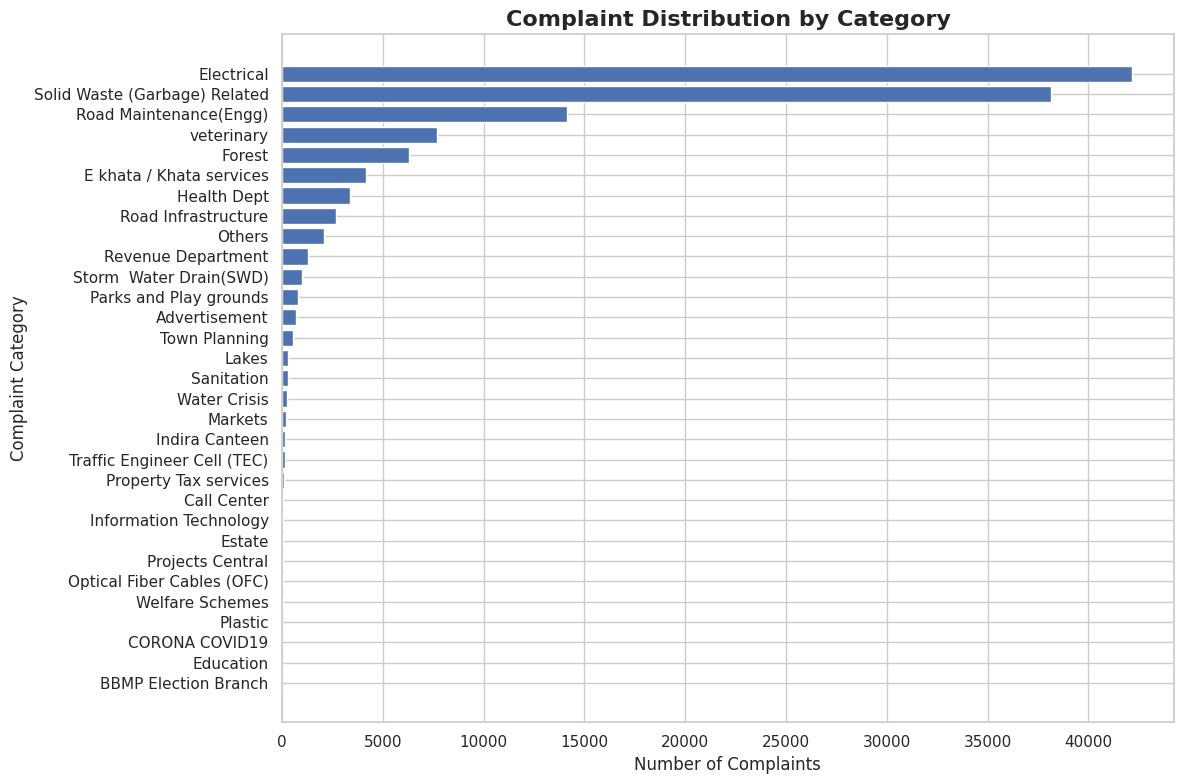

In [ ]:
# Count complaints in each category
category_counts = (
    df["Category"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(12,8))

plt.barh(category_counts.index,
         category_counts.values)

plt.title("Complaint Distribution by Category",
          fontsize=16,
          fontweight="bold")

plt.xlabel("Number of Complaints")
plt.ylabel("Complaint Category")

plt.tight_layout()
plt.show()

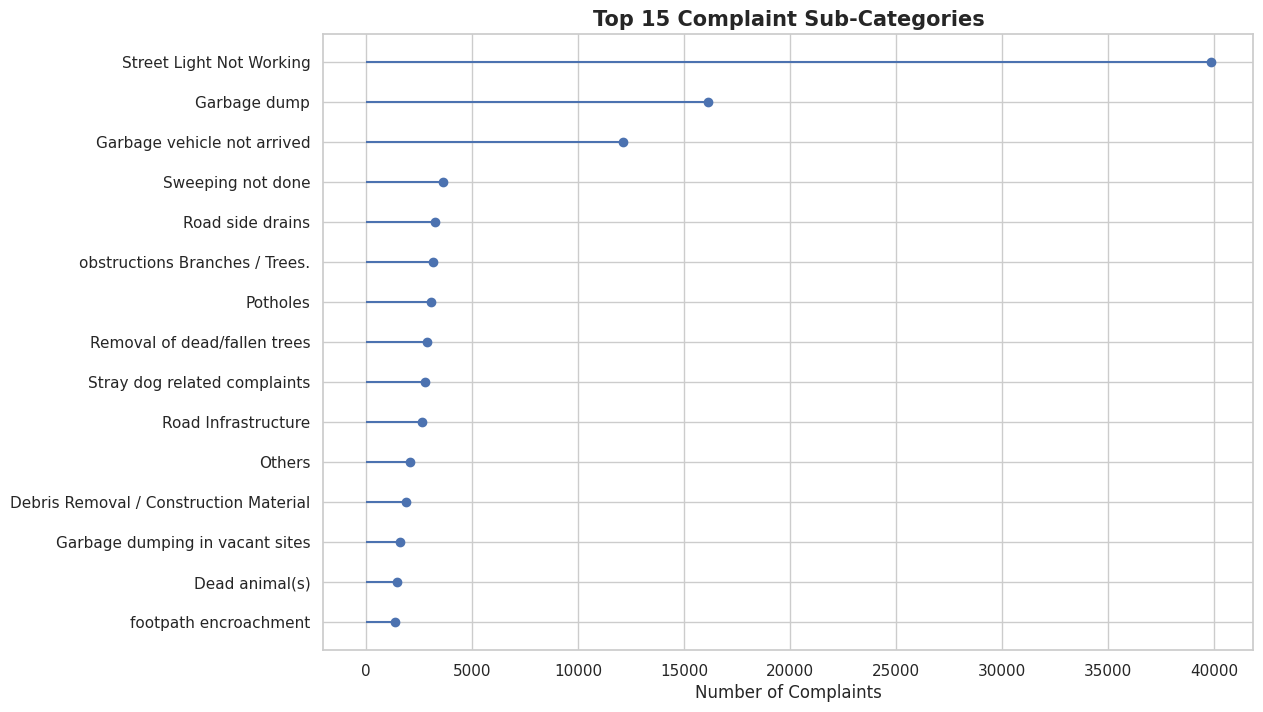

In [ ]:
top_sub = (
    df["Sub Category"]
    .value_counts()
    .head(15)
    .sort_values()
)

plt.figure(figsize=(12,8))

plt.hlines(
    y=top_sub.index,
    xmin=0,
    xmax=top_sub.values
)

plt.plot(
    top_sub.values,
    top_sub.index,
    "o"
)

plt.title("Top 15 Complaint Sub-Categories",
          fontsize=15,
          fontweight="bold")

plt.xlabel("Number of Complaints")

plt.show()

In [ ]:
#omplaint Status Distribution
import plotly.express as px

status = df["Grievance Status"].value_counts().reset_index()
status.columns = ["Status", "Count"]

fig = px.pie(
    status,
    values="Count",
    names="Status",
    hole=0.55,
    title="Complaint Status Distribution"
)

fig.update_traces(textposition='inside', textinfo='percent+label')

fig.show()

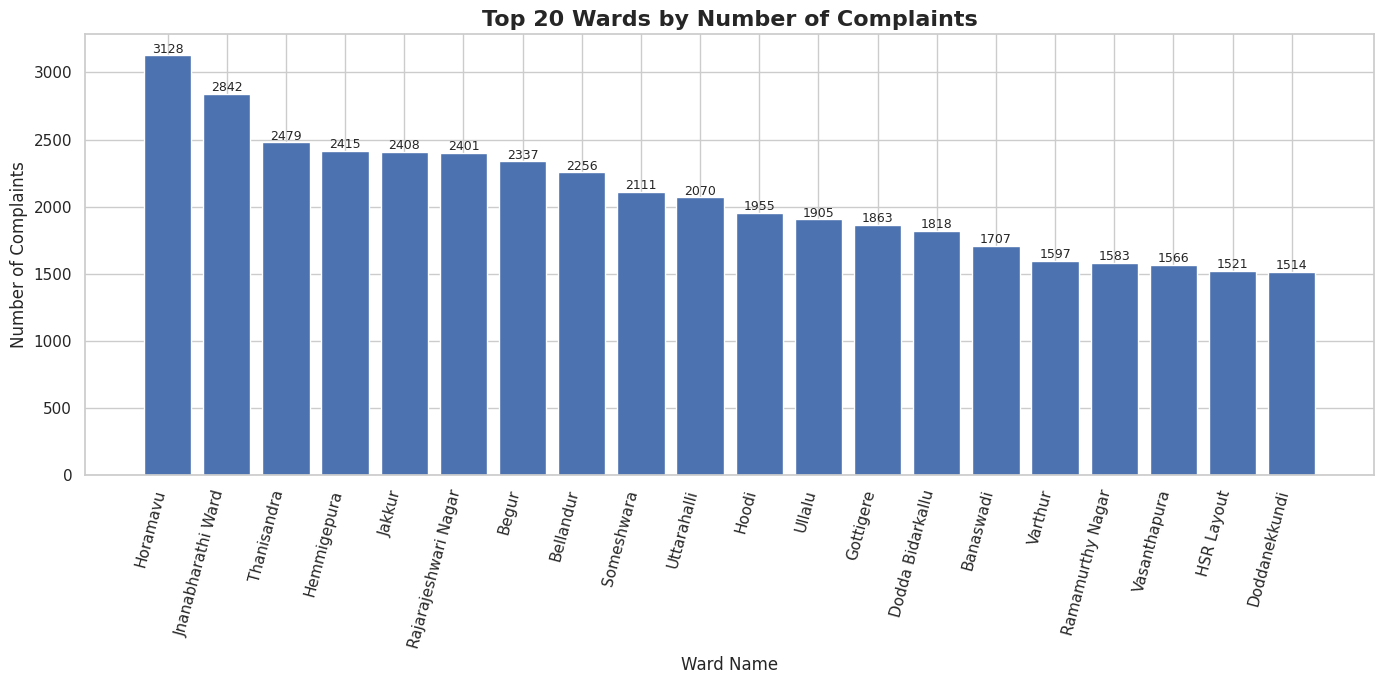

In [ ]:
# Top 20 wards by number of complaints
top_wards = df["Ward Name"].value_counts().head(20)

plt.figure(figsize=(14,7))

bars = plt.bar(top_wards.index, top_wards.values)

plt.title("Top 20 Wards by Number of Complaints", fontsize=16, fontweight="bold")
plt.xlabel("Ward Name", fontsize=12)
plt.ylabel("Number of Complaints", fontsize=12)

plt.xticks(rotation=75, ha='right')

# Add values on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 20,
        f"{int(height)}",
        ha='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()

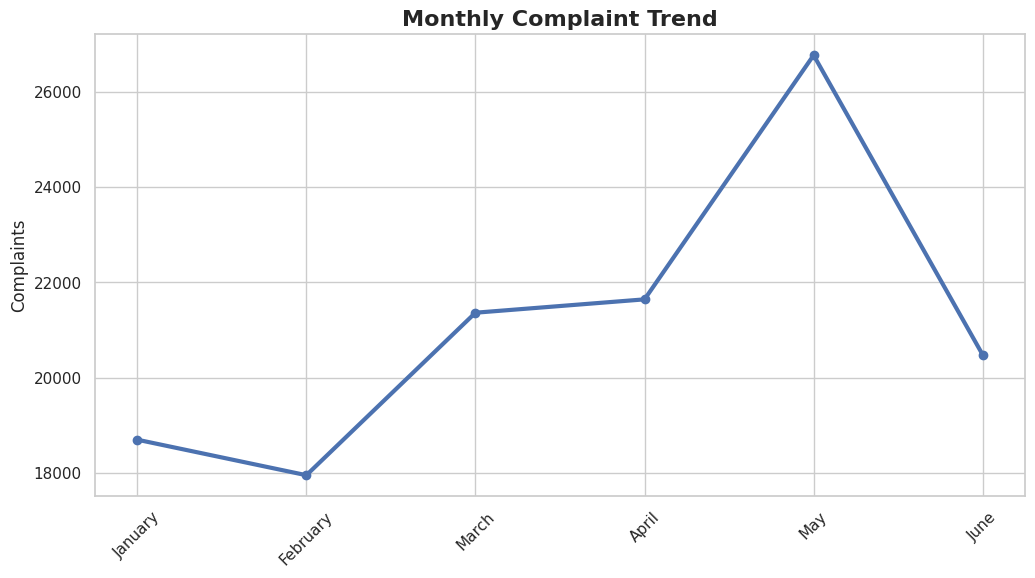

In [ ]:
monthly = (
    df.groupby("Month")
    .size()
)

month_order = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

monthly = monthly.reindex(month_order)

plt.figure(figsize=(12,6))

plt.plot(
    monthly.index,
    monthly.values,
    marker="o",
    linewidth=3
)

plt.xticks(rotation=45)

plt.title("Monthly Complaint Trend",
          fontsize=16,
          fontweight="bold")

plt.ylabel("Complaints")

plt.show()

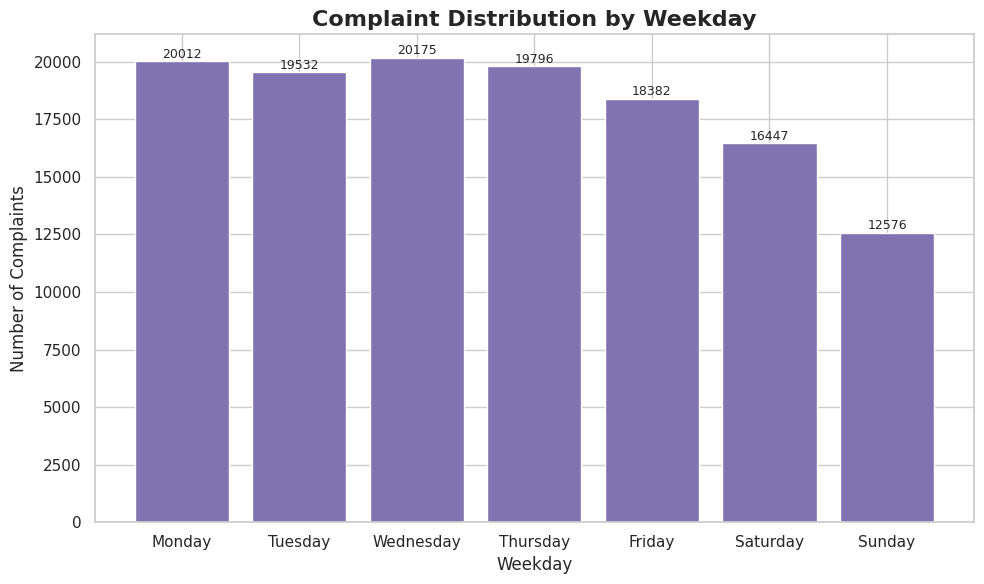

In [ ]:
#EDA 6: Complaint Distribution by Weekday
# Count complaints for each weekday in the correct order
weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

weekday = df["Weekday"].value_counts().reindex(weekday_order)

# Create the figure
plt.figure(figsize=(10,6))

# Plot the graph
bars = plt.bar(
    weekday.index,
    weekday.values,
    color="#8172B2"
)

# Add title and labels
plt.title("Complaint Distribution by Weekday", fontsize=16, fontweight="bold")
plt.xlabel("Weekday")
plt.ylabel("Number of Complaints")

# Add values on top of each bar
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 150,
        int(bar.get_height()),
        ha="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

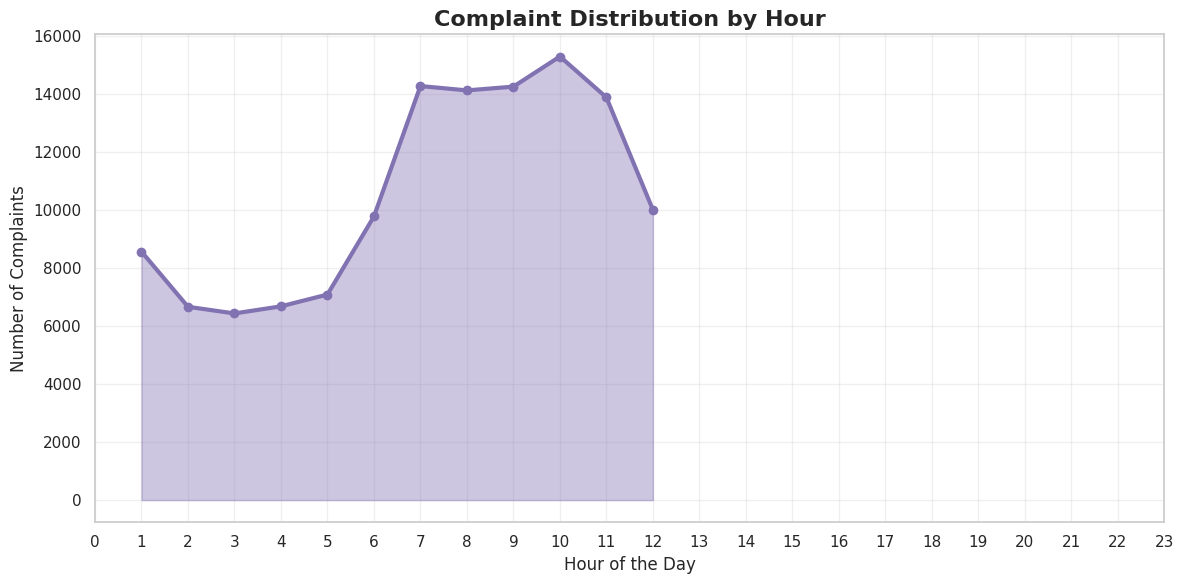

In [ ]:
#EDA 7: Complaint Distribution by Hour
# Count complaints registered during each hour of the day
hourly = df.groupby("Hour").size()

# Create the figure
plt.figure(figsize=(12,6))

# Plot area chart
plt.fill_between(
    hourly.index,
    hourly.values,
    color="#8172B2",
    alpha=0.4
)

# Plot line over the area
plt.plot(
    hourly.index,
    hourly.values,
    color="#8172B2",
    linewidth=3,
    marker="o"
)

# Add title and labels
plt.title("Complaint Distribution by Hour", fontsize=16, fontweight="bold")
plt.xlabel("Hour of the Day")
plt.ylabel("Number of Complaints")

plt.xticks(range(24))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

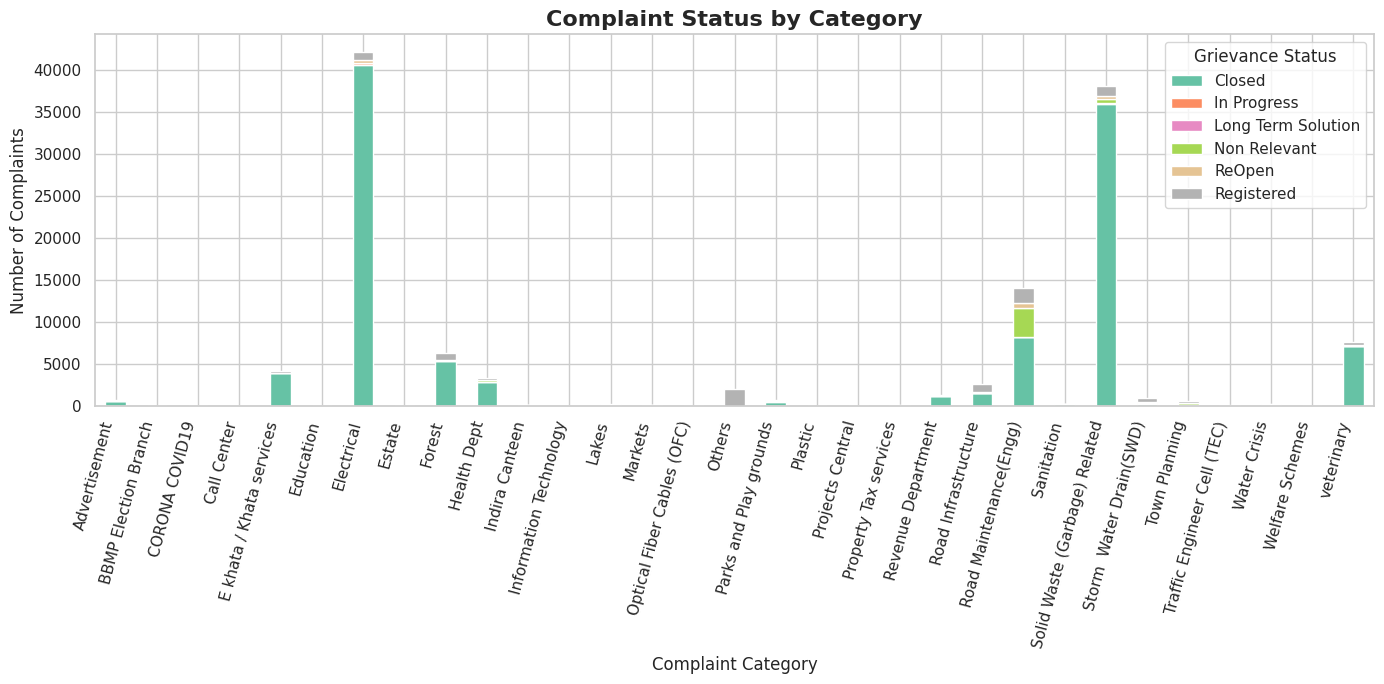

In [ ]:
#EDA 8: Complaint Status by Category
# Create a cross-tabulation of Category and Grievance Status
status_category = pd.crosstab(
    df["Category"],
    df["Grievance Status"]
)

# Plot stacked bar chart
status_category.plot(
    kind="bar",
    stacked=True,
    figsize=(14,7),
    colormap="Set2"
)

plt.title("Complaint Status by Category", fontsize=16, fontweight="bold")
plt.xlabel("Complaint Category")
plt.ylabel("Number of Complaints")

plt.xticks(rotation=75, ha="right")

plt.legend(title="Grievance Status")

plt.tight_layout()
plt.show()

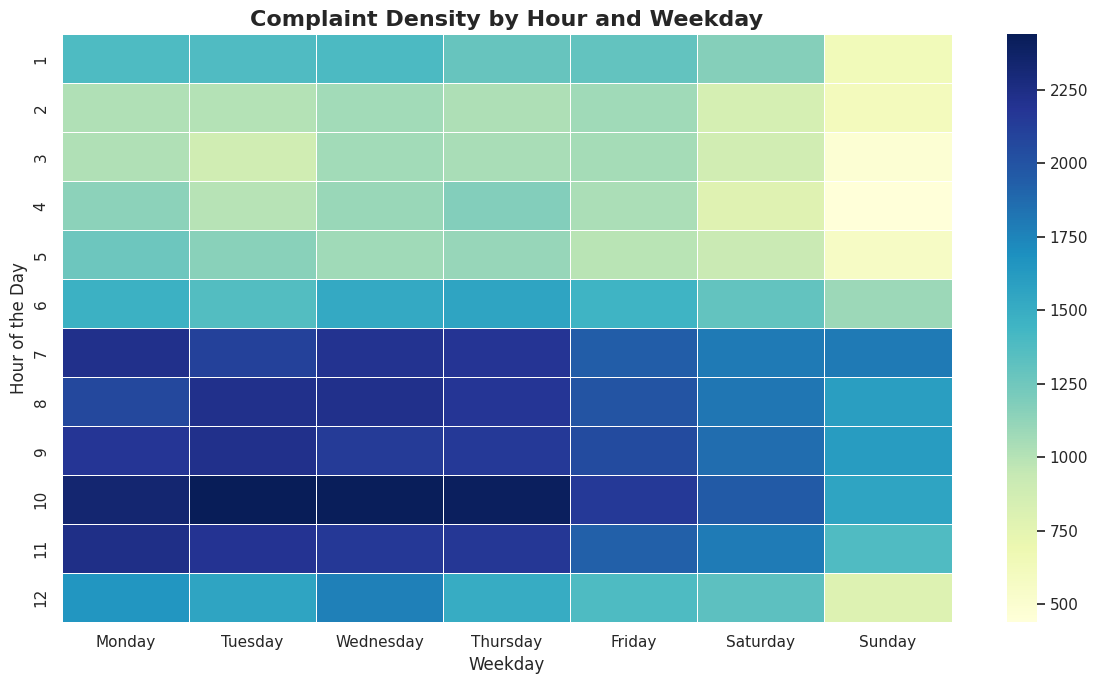

In [ ]:
#EDA 9: Complaint Density by Hour and Weekday

# Create a pivot table of complaint counts by Hour and Weekday
hour_weekday = pd.crosstab(
    df["Hour"],
    df["Weekday"]
)

# Arrange weekdays in chronological order
weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

hour_weekday = hour_weekday.reindex(columns=weekday_order)

# Create the figure
plt.figure(figsize=(12,7))

# Plot heatmap
sns.heatmap(
    hour_weekday,
    cmap="YlGnBu",
    linewidths=0.5,
    linecolor="white"
)

# Add title and labels
plt.title("Complaint Density by Hour and Weekday", fontsize=16, fontweight="bold")
plt.xlabel("Weekday")
plt.ylabel("Hour of the Day")

plt.tight_layout()
plt.show()

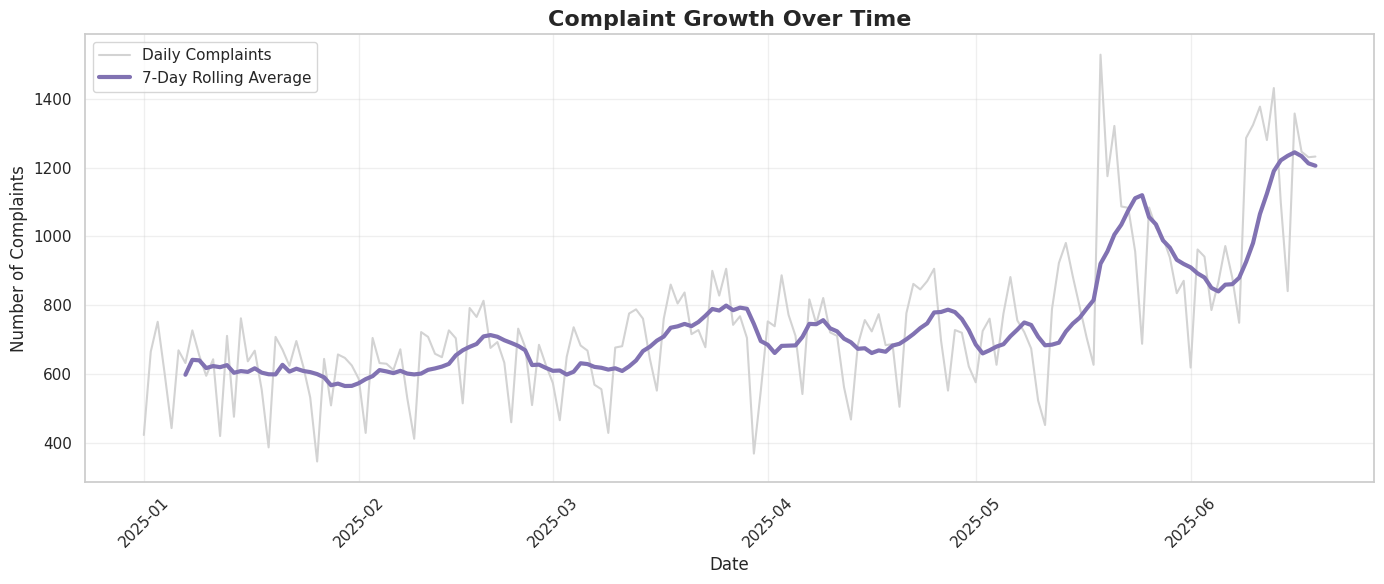

In [ ]:
# EDA 10: Complaint Growth Over Time (7-Day Rolling Average)
# Count daily complaints
daily_complaints = (
    df.groupby(df["Grievance Date"].dt.date)
    .size()
)

# Calculate 7-day rolling average
rolling_avg = daily_complaints.rolling(window=7).mean()

# Create figure
plt.figure(figsize=(14,6))

# Plot daily complaints
plt.plot(
    daily_complaints.index,
    daily_complaints.values,
    color="lightgray",
    linewidth=1.5,
    label="Daily Complaints"
)

# Plot rolling average
plt.plot(
    rolling_avg.index,
    rolling_avg.values,
    color="#8172B2",
    linewidth=3,
    label="7-Day Rolling Average"
)

plt.title("Complaint Growth Over Time", fontsize=16, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Number of Complaints")

plt.legend()

plt.grid(alpha=0.3)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

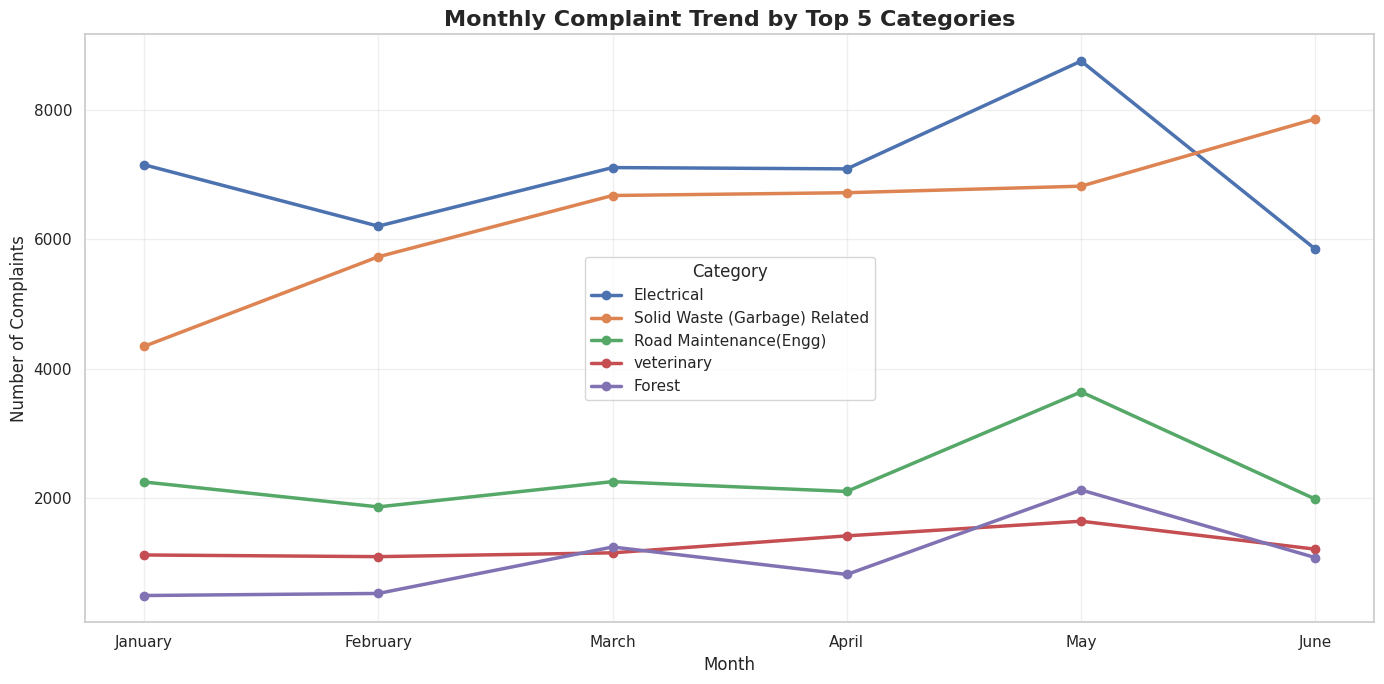

In [ ]:
# EDA 11: Monthly Complaint Trend by Category
# Create a pivot table of monthly complaints by category
monthly_category = pd.crosstab(
    df["Month"],
    df["Category"]
)

# Arrange months in chronological order
month_order = [
    "January", "February", "March",
    "April", "May", "June"
]

monthly_category = monthly_category.reindex(month_order)

# Select the top 5 complaint categories
top_categories = df["Category"].value_counts().head(5).index

# Create figure
plt.figure(figsize=(14,7))

# Plot a line for each category
for category in top_categories:
    plt.plot(
        monthly_category.index,
        monthly_category[category],
        marker='o',
        linewidth=2.5,
        label=category
    )

# Add title and labels
plt.title("Monthly Complaint Trend by Top 5 Categories", fontsize=16, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Number of Complaints")

plt.legend(title="Category")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

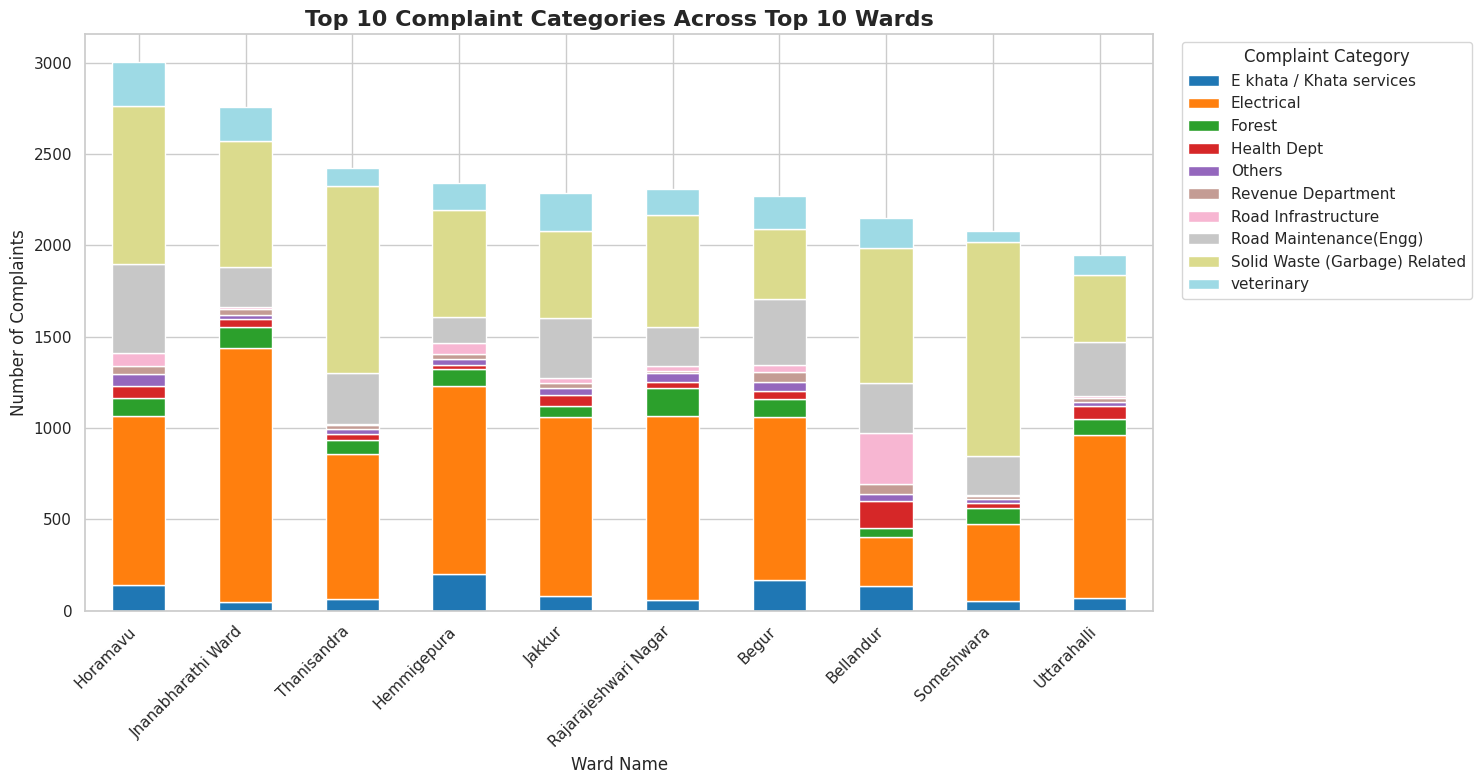

In [ ]:
# EDA 12: Top 10 Complaint Categories Across Top 10 Wards

# Get the top 10 wards with the highest number of complaints
top_wards = df["Ward Name"].value_counts().head(10).index

# Get the top 10 complaint categories
top_categories = df["Category"].value_counts().head(10).index

# Filter the dataset
filtered_df = df[
    (df["Ward Name"].isin(top_wards)) &
    (df["Category"].isin(top_categories))
]

# Create a pivot table
ward_category = pd.crosstab(
    filtered_df["Ward Name"],
    filtered_df["Category"]
)

# Arrange wards by complaint count
ward_category = ward_category.loc[top_wards]

# Plot stacked bar chart
ward_category.plot(
    kind="bar",
    stacked=True,
    figsize=(15,8),
    colormap="tab20"
)

# Add title and labels
plt.title("Top 10 Complaint Categories Across Top 10 Wards",
          fontsize=16,
          fontweight="bold")

plt.xlabel("Ward Name")
plt.ylabel("Number of Complaints")

plt.xticks(rotation=45, ha="right")

plt.legend(
    title="Complaint Category",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [ ]:
# Feature Engineering 1: Is Weekend
# Create Weekend indicator
df["Is Weekend"] = df["Weekday"].isin(["Saturday", "Sunday"]).astype(int)

# Display first few rows
df[["Weekday", "Is Weekend"]].head()

,Weekday,Is Weekend
0,Thursday,0
1,Thursday,0
2,Thursday,0
3,Thursday,0
4,Thursday,0


In [ ]:
# Feature Engineering 2: Time of Day
# Function to classify time of day
def get_time_of_day(hour):
    if 5 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Night"

# Create Time of Day feature
df["Time of Day"] = df["Hour"].apply(get_time_of_day)

# Display first few rows
df[["Hour", "Time of Day"]].head()

,Hour,Time of Day
0,10,Morning
1,10,Morning
2,10,Morning
3,10,Morning
4,10,Morning


In [ ]:
df["Time of Day"].value_counts()

,count
Time of Day,
Morning,88607
Night,28316
Afternoon,9997


In [ ]:
# ============================================================
# Feature Engineering 3: Complaint Count by Ward
# ============================================================

# Count complaints in each ward
ward_count = df["Ward Name"].value_counts()

# Map the counts back to the dataset
df["Ward Complaint Count"] = df["Ward Name"].map(ward_count)

# Display first few rows
df[["Ward Name", "Ward Complaint Count"]].head()

,Ward Name,Ward Complaint Count
0,Jagajeevanram Nagar,290
1,Kammanahalli,431
2,Banaswadi,1707
3,Gandhi Nagar,429
4,Kumaraswamy Layout,899


In [ ]:
# ============================================================
# Feature Engineering 4: Complaint Count by Category
# ============================================================

# Count complaints for each category
category_count = df["Category"].value_counts()

# Map counts back to dataset
df["Category Complaint Count"] = df["Category"].map(category_count)

# Display first few rows
df[["Category", "Category Complaint Count"]].head()

,Category,Category Complaint Count
0,Electrical,42134
1,Electrical,42134
2,Solid Waste (Garbage) Related,38138
3,Electrical,42134
4,Solid Waste (Garbage) Related,38138


In [ ]:
# ============================================================
# Feature Engineering 5: Complaint Count by Sub Category
# ============================================================

# Count complaints for each sub-category
subcategory_count = df["Sub Category"].value_counts()

# Map counts back to dataset
df["Sub Category Complaint Count"] = df["Sub Category"].map(subcategory_count)

# Display first few rows
df[["Sub Category", "Sub Category Complaint Count"]].head()

,Sub Category,Sub Category Complaint Count
0,Street Light Not Working,39844
1,Street Light Not Working,39844
2,Garbage dump,16129
3,Street Light Not Working,39844
4,Garbage dump,16129


In [ ]:
# ============================================================
# Feature Engineering 6: Ward Rank
# ============================================================

# Rank wards based on complaint count
ward_rank = (
    df["Ward Name"]
    .value_counts()
    .rank(method="dense", ascending=False)
    .astype(int)
)

# Map ranks back to the dataset
df["Ward Rank"] = df["Ward Name"].map(ward_rank)

# Display first few rows
df[["Ward Name", "Ward Rank"]].head()

,Ward Name,Ward Rank
0,Jagajeevanram Nagar,125
1,Kammanahalli,95
2,Banaswadi,15
3,Gandhi Nagar,96
4,Kumaraswamy Layout,42


In [ ]:
# ============================================================
# Feature Engineering 7: Peak Hour
# ============================================================

# Calculate complaint count by hour
hour_counts = df["Hour"].value_counts()

# Define peak hours as hours above the median complaint count
threshold = hour_counts.median()

peak_hours = hour_counts[hour_counts > threshold].index

# Create Peak Hour feature
df["Peak Hour"] = df["Hour"].isin(peak_hours).astype(int)

# Display first few rows
df[["Hour", "Peak Hour"]].head()

,Hour,Peak Hour
0,10,1
1,10,1
2,10,1
3,10,1
4,10,1


In [ ]:
# ============================================================
# Feature Engineering 8: Season
# ============================================================

def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Summer"
    elif month in [6, 7, 8, 9]:
        return "Monsoon"
    else:
        return "Post-Monsoon"

df["Season"] = df["Grievance Date"].dt.month.apply(get_season)

# Display first few rows
df[["Month", "Season"]].head()

,Month,Season
0,June,Monsoon
1,June,Monsoon
2,June,Monsoon
3,June,Monsoon
4,June,Monsoon


In [ ]:
# ============================================================
# Save Final Engineered Dataset
# ============================================================

df.to_csv("engineered_dataset.csv", index=False)

print("Engineered dataset saved successfully!")

Engineered dataset saved successfully!


In [ ]:
# ============================================================
# Import Required Libraries
# ============================================================

# Import libraries required for machine learning and visualization.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [ ]:
# ============================================================
# Dataset Validation
# ============================================================

# Check the size of the dataset
print("Dataset Shape :", df.shape)

# Check data types
print("\nDataset Information")
df.info()

# Check missing values
print("\nMissing Values")
print(df.isnull().sum())

# Check duplicate records
print("\nDuplicate Records :", df.duplicated().sum())

# Display first few rows
df.head()

Dataset Shape : (126920, 21)

Dataset Information
<class 'pandas.core.frame.DataFrame'>
Index: 126920 entries, 0 to 126973
Data columns (total 21 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   Complaint ID                  126920 non-null  int64         
 1   Category                      126920 non-null  object        
 2   Sub Category                  126920 non-null  object        
 3   Grievance Date                126920 non-null  datetime64[ns]
 4   Ward Name                     126920 non-null  object        
 5   Grievance Status              126920 non-null  object        
 6   Staff Remarks                 126920 non-null  object        
 7   Staff Name                    126920 non-null  object        
 8   Year                          126920 non-null  int32         
 9   Month                         126920 non-null  object        
 10  Day                           12692

,Complaint ID,Category,Sub Category,Grievance Date,Ward Name,Grievance Status,Staff Remarks,Staff Name,Year,Month,...,Weekday,Hour,Season,Is Weekend,Time of Day,Ward Complaint Count,Category Complaint Count,Sub Category Complaint Count,Ward Rank,Peak Hour
0,20771690,Electrical,Street Light Not Working,2025-06-19 10:39:00,Jagajeevanram Nagar,Registered,1st Assignment Based on Ward Mapping,syed zameer/JE,2025,June,...,Thursday,10,Monsoon,0,Morning,290,42134,39844,125,1
1,20771689,Electrical,Street Light Not Working,2025-06-19 10:36:00,Kammanahalli,Registered,1st Assignment Based on Ward Mapping,Vinay Kumar/AE,2025,June,...,Thursday,10,Monsoon,0,Morning,431,42134,39844,95,1
2,20771688,Solid Waste (Garbage) Related,Garbage dump,2025-06-19 10:35:00,Banaswadi,Registered,1st Assignment Based on Ward Mapping,Marshal Ward No 27/Marshal,2025,June,...,Thursday,10,Monsoon,0,Morning,1707,38138,16129,15,1
3,20771687,Electrical,Street Light Not Working,2025-06-19 10:34:00,Gandhi Nagar,Registered,1st Assignment Based on Ward Mapping,syed zameer/JE,2025,June,...,Thursday,10,Monsoon,0,Morning,429,42134,39844,96,1
4,20771686,Solid Waste (Garbage) Related,Garbage dump,2025-06-19 10:34:00,Kumaraswamy Layout,Registered,1st Assignment Based on Ward Mapping,Marshal Ward No 181/Marshal,2025,June,...,Thursday,10,Monsoon,0,Morning,899,38138,16129,42,1


In [ ]:
# ============================================================
# Create Priority Labels
# ============================================================

critical = [
    "Electrical",
    "Storm  Water Drain(SWD)",
    "Road Infrastructure",
    "Road Maintenance(Engg)",
    "Water Crisis",
    "Health Dept"
]

moderate = [
    "Solid Waste (Garbage) Related",
    "Sanitation",
    "Forest",
    "Parks and Play grounds",
    "Lakes",
    "veterinary"
]


def assign_priority(row):

    # Highest priority civic complaints
    if row["Category"] in critical:
        return "Critical"

    # Frequently occurring complaints
    elif row["Category"] in moderate:
        return "Moderate"

    # High complaint wards are upgraded
    elif row["Ward Complaint Count"] > df["Ward Complaint Count"].quantile(0.75):
        return "Moderate"

    # Peak-hour complaints are upgraded
    elif row["Peak Hour"] == 1:
        return "Moderate"

    else:
        return "Routine"


df["Priority"] = df.apply(assign_priority, axis=1)

print(df["Priority"].value_counts())

Priority
Critical    63531
Moderate    59933
Routine      3456
Name: count, dtype: int64


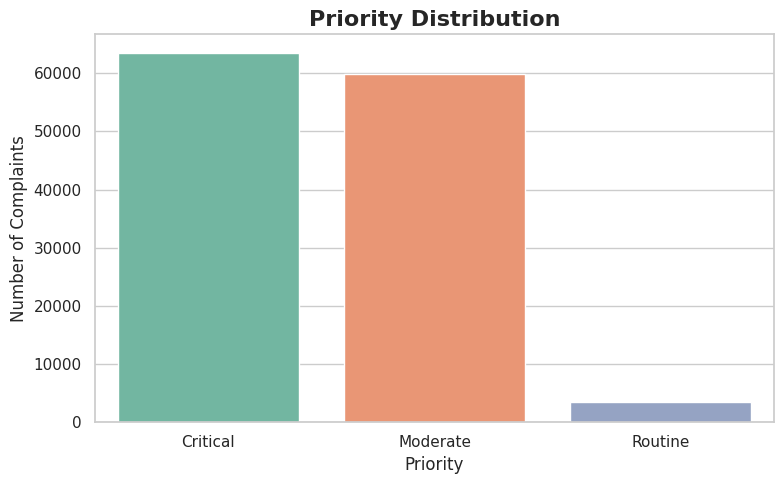

In [ ]:
# ============================================================
# Priority Distribution
# ============================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Priority",
    order=["Critical","Moderate","Routine"],
    palette="Set2"
)

plt.title(
    "Priority Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Priority")

plt.ylabel("Number of Complaints")

plt.tight_layout()

plt.show()

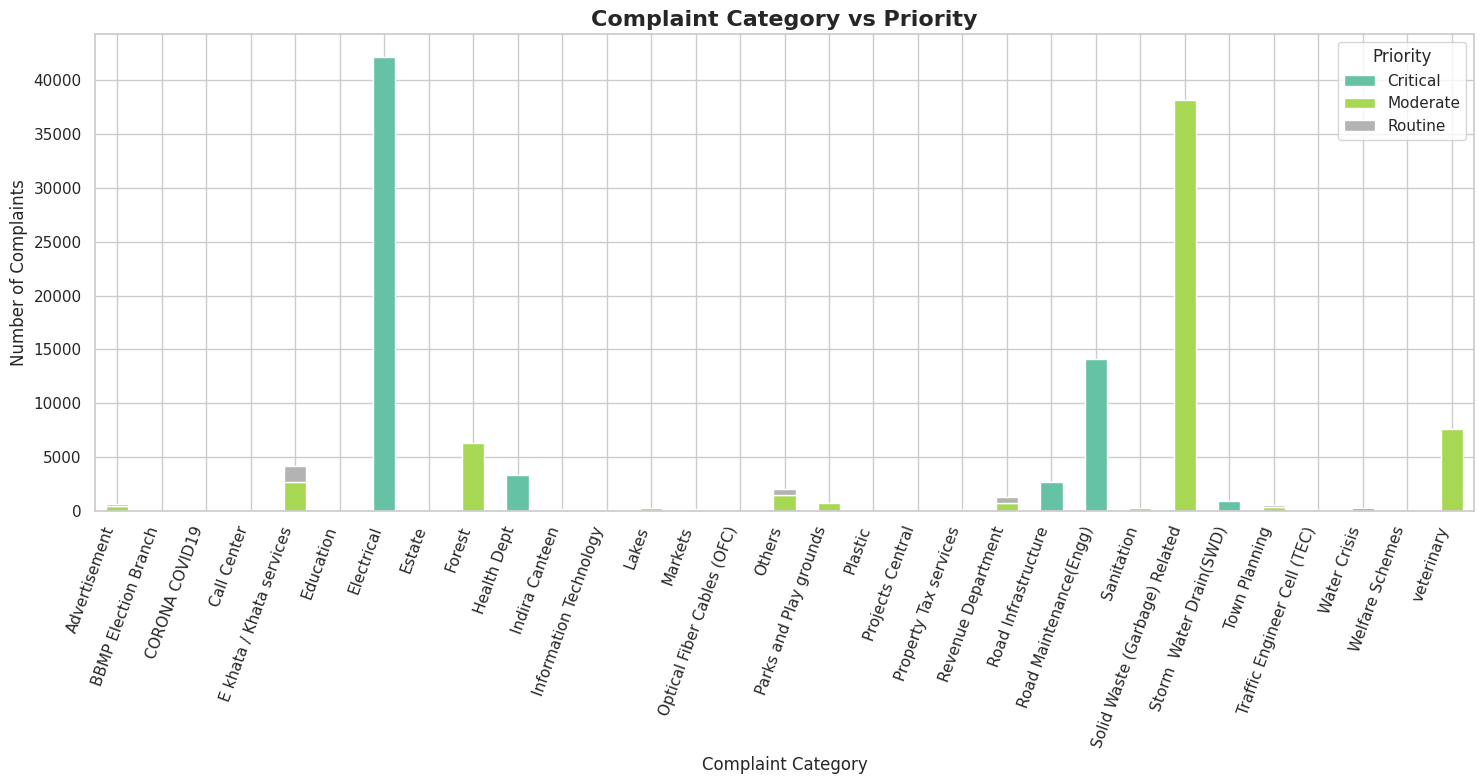

In [ ]:
# ============================================================
# Complaint Category vs Priority
# ============================================================

category_priority = pd.crosstab(
    df["Category"],
    df["Priority"]
)

category_priority.plot(
    kind="bar",
    stacked=True,
    figsize=(15,8),
    colormap="Set2"
)

plt.title(
    "Complaint Category vs Priority",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Complaint Category")

plt.ylabel("Number of Complaints")

plt.xticks(rotation=70, ha="right")

plt.legend(title="Priority")

plt.tight_layout()

plt.show()

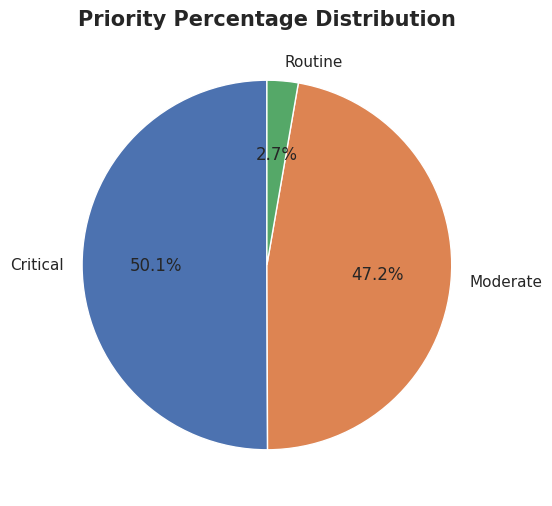

In [ ]:
# ============================================================
# Priority Percentage
# ============================================================

priority_percent = (
    df["Priority"]
    .value_counts(normalize=True)
    * 100
)

plt.figure(figsize=(6,6))

plt.pie(
    priority_percent,
    labels=priority_percent.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Priority Percentage Distribution",
    fontsize=15,
    fontweight="bold"
)

plt.show()

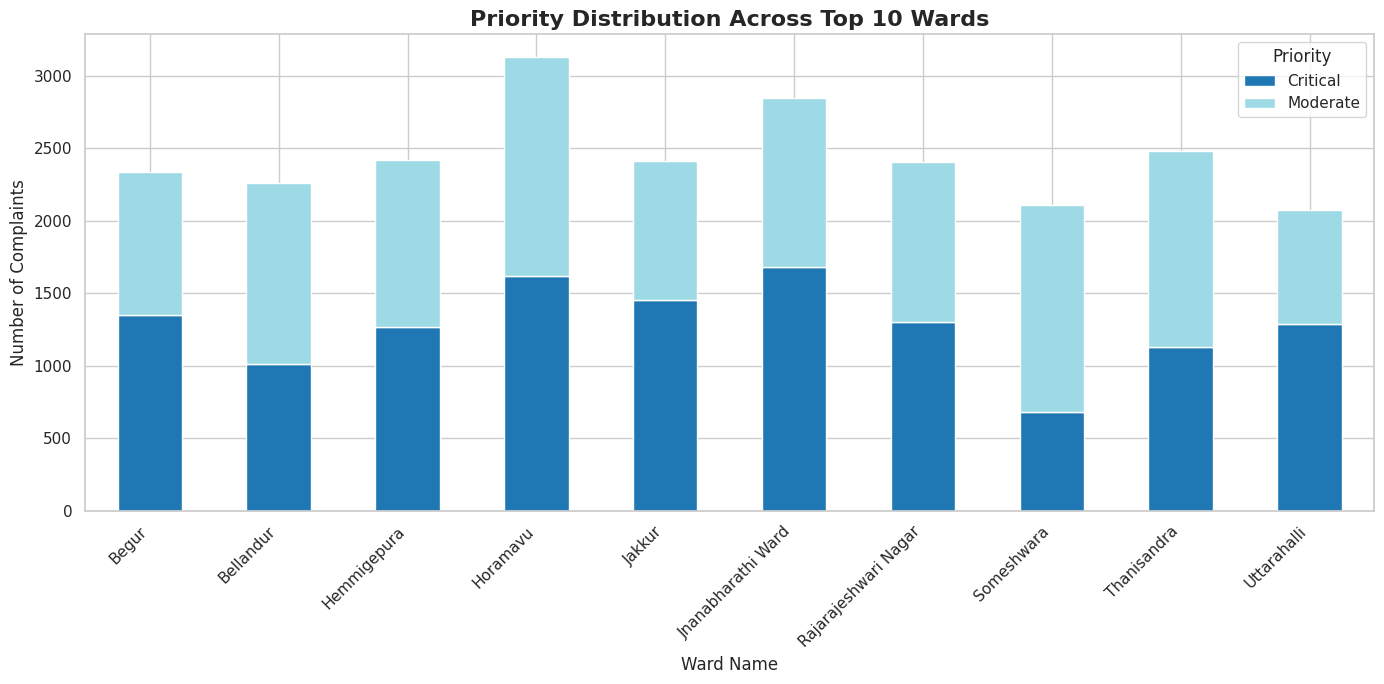

In [ ]:
# ============================================================
# Ward-wise Priority Distribution
# ============================================================

# Top 10 wards based on complaint count
top_wards = df["Ward Name"].value_counts().head(10).index

# Filter dataset
ward_df = df[df["Ward Name"].isin(top_wards)]

# Cross-tabulation
ward_priority = pd.crosstab(
    ward_df["Ward Name"],
    ward_df["Priority"]
)

# Plot
ward_priority.plot(
    kind="bar",
    stacked=True,
    figsize=(14,7),
    colormap="tab20"
)

plt.title(
    "Priority Distribution Across Top 10 Wards",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Ward Name")
plt.ylabel("Number of Complaints")

plt.xticks(rotation=45, ha="right")

plt.legend(title="Priority")

plt.tight_layout()
plt.show()

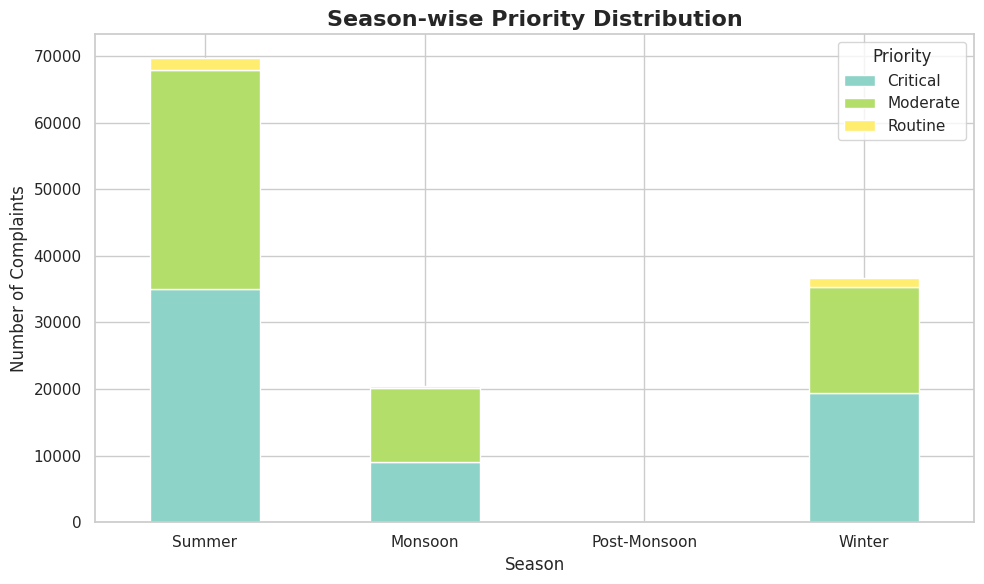

In [ ]:
# ============================================================
# Season vs Priority
# ============================================================

season_priority = pd.crosstab(
    df["Season"],
    df["Priority"]
)

season_priority = season_priority.reindex(
    ["Summer","Monsoon","Post-Monsoon","Winter"]
)

season_priority.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6),
    colormap="Set3"
)

plt.title(
    "Season-wise Priority Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Season")
plt.ylabel("Number of Complaints")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

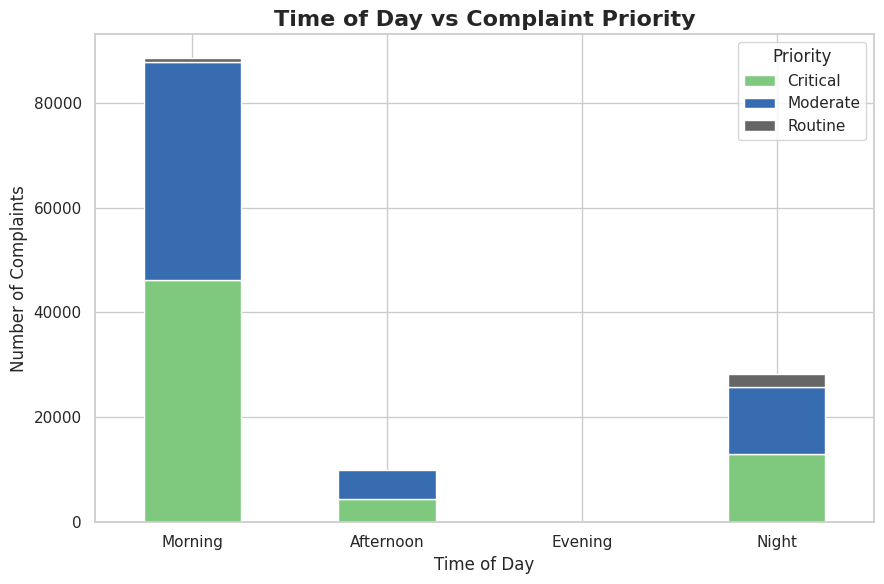

In [ ]:
# ============================================================
# Time of Day vs Priority
# ============================================================

time_priority = pd.crosstab(
    df["Time of Day"],
    df["Priority"]
)

order = [
    "Morning",
    "Afternoon",
    "Evening",
    "Night"
]

time_priority = time_priority.reindex(order)

time_priority.plot(
    kind="bar",
    stacked=True,
    figsize=(9,6),
    colormap="Accent"
)

plt.title(
    "Time of Day vs Complaint Priority",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Time of Day")
plt.ylabel("Number of Complaints")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

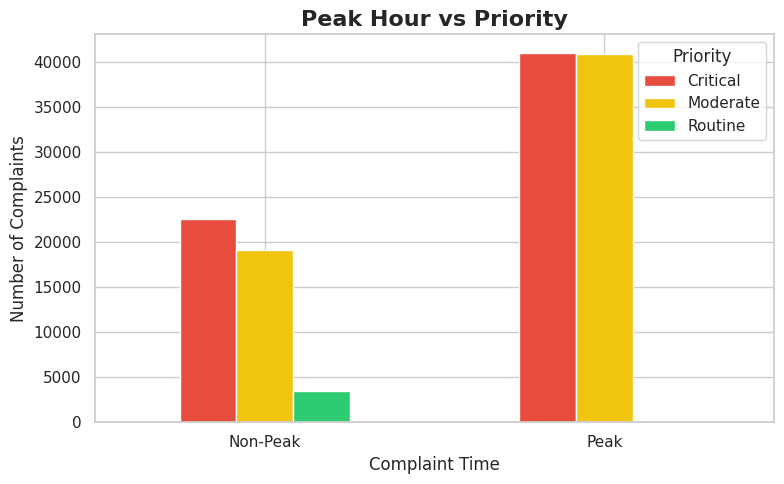

In [ ]:
# ============================================================
# Peak Hour vs Priority
# ============================================================

peak_priority = pd.crosstab(
    df["Peak Hour"],
    df["Priority"]
)

peak_priority.index = ["Non-Peak","Peak"]

peak_priority.plot(
    kind="bar",
    figsize=(8,5),
    color=["#E74C3C","#F1C40F","#2ECC71"]
)

plt.title(
    "Peak Hour vs Priority",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Complaint Time")
plt.ylabel("Number of Complaints")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

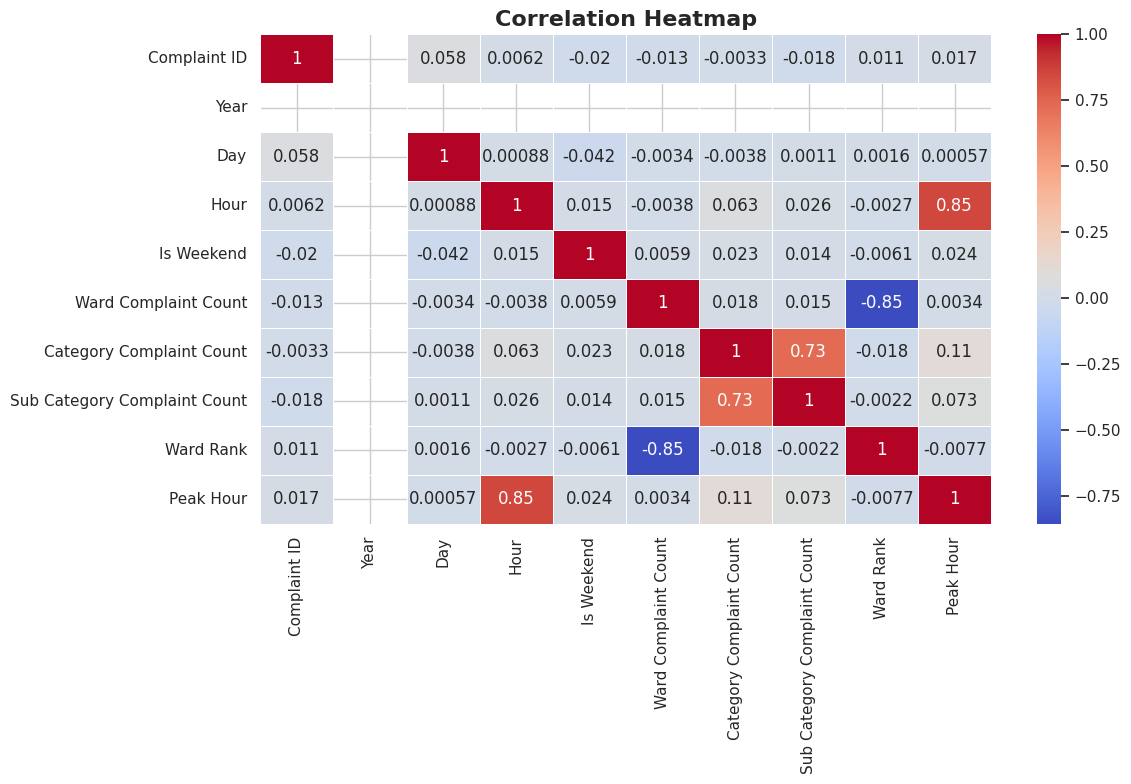

In [ ]:
# ============================================================
# Correlation Heatmap
# ============================================================

numeric = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title(
    "Correlation Heatmap",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Multicollinearity Check
# ============================================================

corr = numeric.corr().abs()

upper = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)

high_corr = [
    column
    for column in upper.columns
    if any(upper[column] > 0.90)
]

print("Highly Correlated Features (>0.90):")
print(high_corr)

Highly Correlated Features (>0.90):
[]


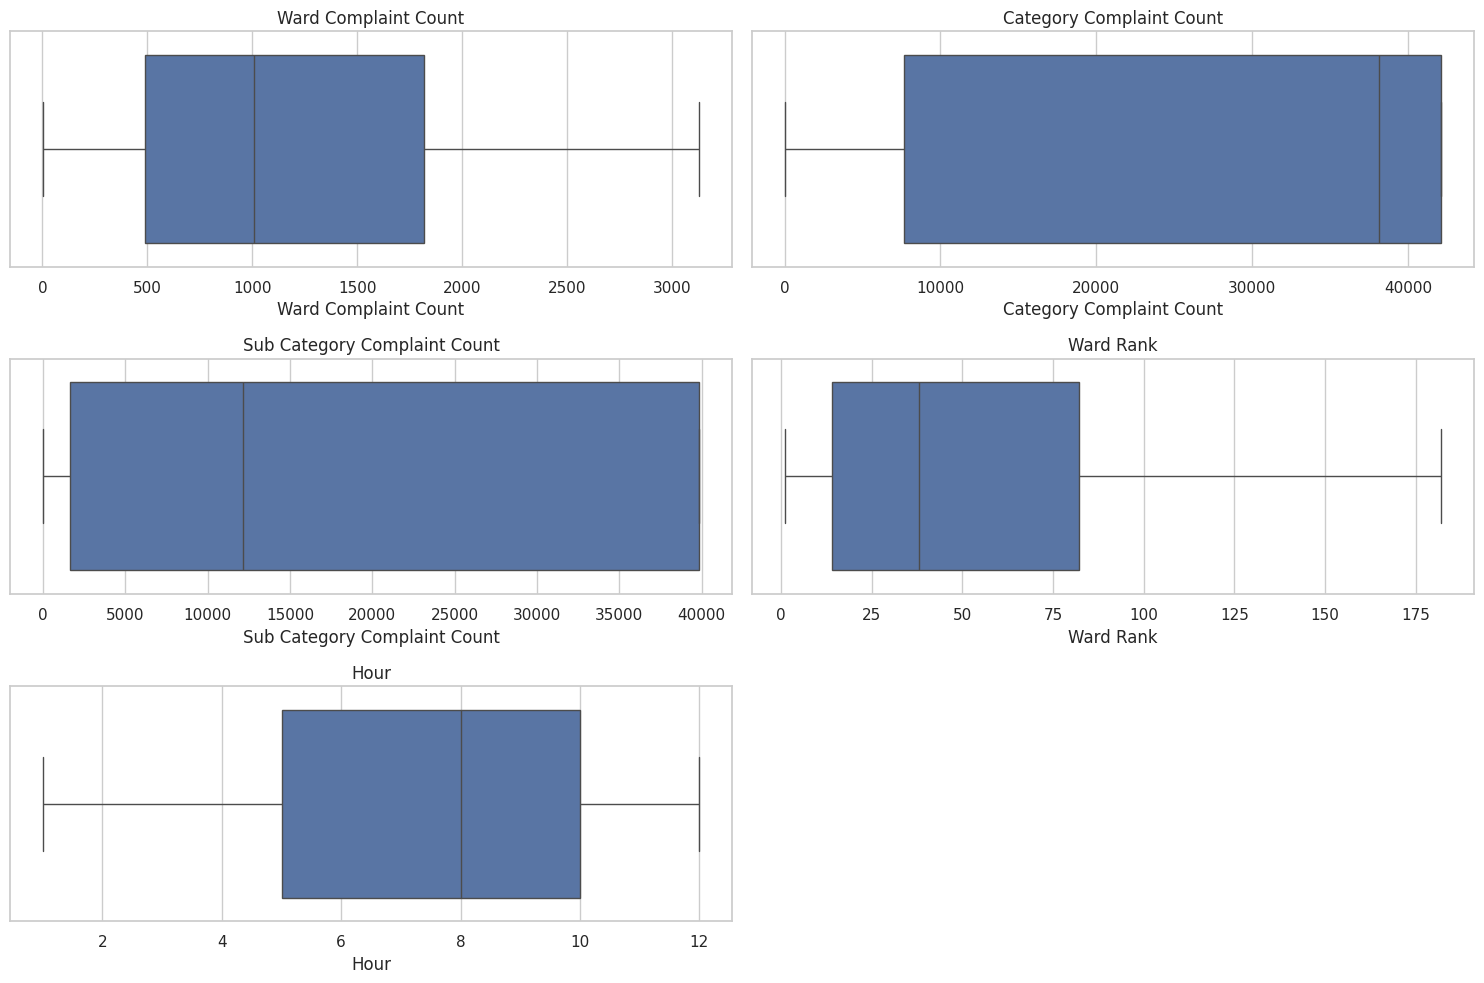

In [ ]:
# ============================================================
# Outlier Detection
# ============================================================

features = [
    "Ward Complaint Count",
    "Category Complaint Count",
    "Sub Category Complaint Count",
    "Ward Rank",
    "Hour"
]

plt.figure(figsize=(15,10))

for i, feature in enumerate(features):

    plt.subplot(3,2,i+1)

    sns.boxplot(
        x=df[feature]
    )

    plt.title(feature)

plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# Model-Oriented EDA Insights
# ============================================================

print("1. Complaint priorities are distributed across three classes.")
print("2. Certain wards receive significantly more critical complaints.")
print("3. Seasonal variations influence complaint priorities.")
print("4. Peak hours experience a higher number of complaints.")
print("5. Numerical features show varying levels of correlation.")
print("6. Outliers are present but are retained since they represent genuine municipal complaint patterns.")

1. Complaint priorities are distributed across three classes.
2. Certain wards receive significantly more critical complaints.
3. Seasonal variations influence complaint priorities.
4. Peak hours experience a higher number of complaints.
5. Numerical features show varying levels of correlation.
6. Outliers are present but are retained since they represent genuine municipal complaint patterns.


In [ ]:
# ============================================================
# Label Encoding
# ============================================================

from sklearn.preprocessing import LabelEncoder

# Create LabelEncoder object
le = LabelEncoder()

# Encode categorical columns
categorical_columns = [
    "Category",
    "Sub Category",
    "Ward Name",
    "Weekday",
    "Season",
    "Time of Day",
    "Priority",
    "Month" # Add 'Month' to the list of columns to be encoded
]

for column in categorical_columns:
    df[column] = le.fit_transform(df[column])

print("Categorical features encoded successfully.")

Categorical features encoded successfully.


In [ ]:
# ============================================================
# Feature Selection
# ============================================================

X = df[
[
    "Category",
    "Sub Category",
    "Ward Name",
    "Month",
    "Hour",
    "Weekday",
    "Season",
    "Is Weekend",
    "Time of Day",
    "Ward Complaint Count",
    "Category Complaint Count",
    "Sub Category Complaint Count",
    "Ward Rank",
    "Peak Hour"
]
]

y = df["Priority"]

print("Feature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Matrix Shape : (126920, 14)
Target Shape : (126920,)


In [ ]:
# ============================================================
# Train Test Split
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print("Training Samples :", X_train.shape)

print("Testing Samples :", X_test.shape)

Training Samples : (101536, 14)
Testing Samples : (25384, 14)


In [ ]:
# ============================================================
# Feature Scaling
# ============================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed.")

Feature Scaling Completed.


In [ ]:
# ============================================================
# Model Training and Evaluation
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Initialize models
log_reg = LogisticRegression(random_state=42)
dec_tree = DecisionTreeClassifier(random_state=42)
rand_forest = RandomForestClassifier(random_state=42)

models = {
    "Logistic Regression": log_reg,
    "Decision Tree": dec_tree,
    "Random Forest": rand_forest
}

# Train and evaluate each model
results = {}
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    print(f"{name} Accuracy: {accuracy:.4f}\n")

print("Model Training and Evaluation Completed.")
print("\n--- Model Accuracies ---")
for name, accuracy in results.items():
    print(f"{name}: {accuracy:.4f}")

Training Logistic Regression...
Logistic Regression Accuracy: 0.7645

Training Decision Tree...
Decision Tree Accuracy: 1.0000

Training Random Forest...
Random Forest Accuracy: 1.0000

Model Training and Evaluation Completed.

--- Model Accuracies ---
Logistic Regression: 0.7645
Decision Tree: 1.0000
Random Forest: 1.0000


In [ ]:
# ============================================================
# Logistic Regression
# ============================================================

from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(

    max_iter=1000,

    random_state=42
)

log_model.fit(

    X_train_scaled,

    y_train

)

log_predictions = log_model.predict(

    X_test_scaled

)

print("Logistic Regression Model Trained Successfully.")

Logistic Regression Model Trained Successfully.


In [ ]:
# ============================================================
# Decision Tree
# ============================================================

from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(

    random_state=42,

    max_depth=12

)

tree_model.fit(

    X_train,

    y_train

)

tree_predictions = tree_model.predict(

    X_test

)

print("Decision Tree Model Trained Successfully.")

Decision Tree Model Trained Successfully.


In [ ]:
# ============================================================
# Random Forest
# ============================================================

from sklearn.ensemble import RandomForestClassifier

forest_model = RandomForestClassifier(

    n_estimators=100,

    random_state=42

)

forest_model.fit(

    X_train,

    y_train

)

forest_predictions = forest_model.predict(

    X_test

)

print("Random Forest Model Trained Successfully.")

Random Forest Model Trained Successfully.


In [ ]:
# ============================================================
# Training Summary
# ============================================================

print("Models Trained Successfully")

print()

print("1. Logistic Regression")

print("2. Decision Tree")

print("3. Random Forest")

Models Trained Successfully

1. Logistic Regression
2. Decision Tree
3. Random Forest


In [ ]:
# ============================================================
# Improved Target Creation (Optimized)
# ============================================================

# Calculate quantiles only once
ward_q75 = df["Ward Complaint Count"].quantile(0.75)
category_q75 = df["Category Complaint Count"].quantile(0.75)

# Use sets for faster lookup
critical_categories = {
    "Electrical",
    "Storm  Water Drain(SWD)",
    "Road Infrastructure",
    "Road Maintenance(Engg)",
    "Water Crisis",
    "Health Dept"
}

moderate_categories = {
    "Solid Waste (Garbage) Related",
    "Sanitation",
    "Forest",
    "Parks and Play grounds",
    "Lakes",
    "veterinary"
}


def assign_priority_v2(row):

    score = 0

    # Base severity from complaint category
    if row["Category"] in critical_categories:
        score += 3
    elif row["Category"] in moderate_categories:
        score += 2
    else:
        score += 1

    # Busy ward
    if row["Ward Complaint Count"] >= ward_q75:
        score += 2

    # Frequently occurring complaint category
    if row["Category Complaint Count"] >= category_q75:
        score += 2

    # Peak hour
    if row["Peak Hour"] == 1:
        score += 1

    # Weekend
    if row["Is Weekend"] == 1:
        score += 1

    # Monsoon
    if row["Season"] == "Monsoon":
        score += 1

    # Final priority
    if score >= 7:
        return "Critical"
    elif score >= 4:
        return "Moderate"
    else:
        return "Routine"


# Create the target column
df["Priority_v2"] = df.apply(assign_priority_v2, axis=1)

# Check class distribution
print(df["Priority_v2"].value_counts())

Priority_v2
Routine     78069
Moderate    46886
Critical     1965
Name: count, dtype: int64


In [ ]:
# ============================================================
# New Feature Matrix (Reduced Data Leakage)
# ============================================================

X = df[
[
    "Sub Category",
    "Ward Name",
    "Month",
    "Hour",
    "Weekday",
    "Season",
    "Is Weekend",
    "Time of Day",
    "Ward Complaint Count",
    "Category Complaint Count",
    "Sub Category Complaint Count",
    "Ward Rank",
    "Peak Hour"
]
]

y = df["Priority_v2"]

In [ ]:
# ============================================================
# MODEL EVALUATION
# ============================================================

# Evaluate the performance of all trained models.

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [ ]:
# ============================================================
# Logistic Regression Evaluation
# ============================================================

log_accuracy = accuracy_score(y_test, log_predictions)
log_precision = precision_score(y_test, log_predictions, average="weighted")
log_recall = recall_score(y_test, log_predictions, average="weighted")
log_f1 = f1_score(y_test, log_predictions, average="weighted")

print("="*60)
print("LOGISTIC REGRESSION")
print("="*60)

print(f"Accuracy : {log_accuracy:.4f}")
print(f"Precision: {log_precision:.4f}")
print(f"Recall   : {log_recall:.4f}")
print(f"F1 Score : {log_f1:.4f}")

print("\nClassification Report\n")
print(classification_report(y_test, log_predictions))

LOGISTIC REGRESSION
Accuracy : 0.7645
Precision: 0.7716
Recall   : 0.7645
F1 Score : 0.7637

Classification Report

              precision    recall  f1-score   support

           0       0.82      0.70      0.75     12706
           1       0.73      0.83      0.78     11987
           2       0.65      0.81      0.72       691

    accuracy                           0.76     25384
   macro avg       0.73      0.78      0.75     25384
weighted avg       0.77      0.76      0.76     25384



In [ ]:
# ============================================================
# Decision Tree Evaluation
# ============================================================

tree_accuracy = accuracy_score(y_test, tree_predictions)
tree_precision = precision_score(y_test, tree_predictions, average="weighted")
tree_recall = recall_score(y_test, tree_predictions, average="weighted")
tree_f1 = f1_score(y_test, tree_predictions, average="weighted")

print("="*60)
print("DECISION TREE")
print("="*60)

print(f"Accuracy : {tree_accuracy:.4f}")
print(f"Precision: {tree_precision:.4f}")
print(f"Recall   : {tree_recall:.4f}")
print(f"F1 Score : {tree_f1:.4f}")

print("\nClassification Report\n")
print(classification_report(y_test, tree_predictions))

DECISION TREE
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     12706
           1       1.00      1.00      1.00     11987
           2       1.00      1.00      1.00       691

    accuracy                           1.00     25384
   macro avg       1.00      1.00      1.00     25384
weighted avg       1.00      1.00      1.00     25384



In [ ]:
# ============================================================
# Random Forest Evaluation
# ============================================================

forest_accuracy = accuracy_score(y_test, forest_predictions)
forest_precision = precision_score(y_test, forest_predictions, average="weighted")
forest_recall = recall_score(y_test, forest_predictions, average="weighted")
forest_f1 = f1_score(y_test, forest_predictions, average="weighted")

print("="*60)
print("RANDOM FOREST")
print("="*60)

print(f"Accuracy : {forest_accuracy:.4f}")
print(f"Precision: {forest_precision:.4f}")
print(f"Recall   : {forest_recall:.4f}")
print(f"F1 Score : {forest_f1:.4f}")

print("\nClassification Report\n")
print(classification_report(y_test, forest_predictions))

RANDOM FOREST
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     12706
           1       1.00      1.00      1.00     11987
           2       1.00      1.00      1.00       691

    accuracy                           1.00     25384
   macro avg       1.00      1.00      1.00     25384
weighted avg       1.00      1.00      1.00     25384



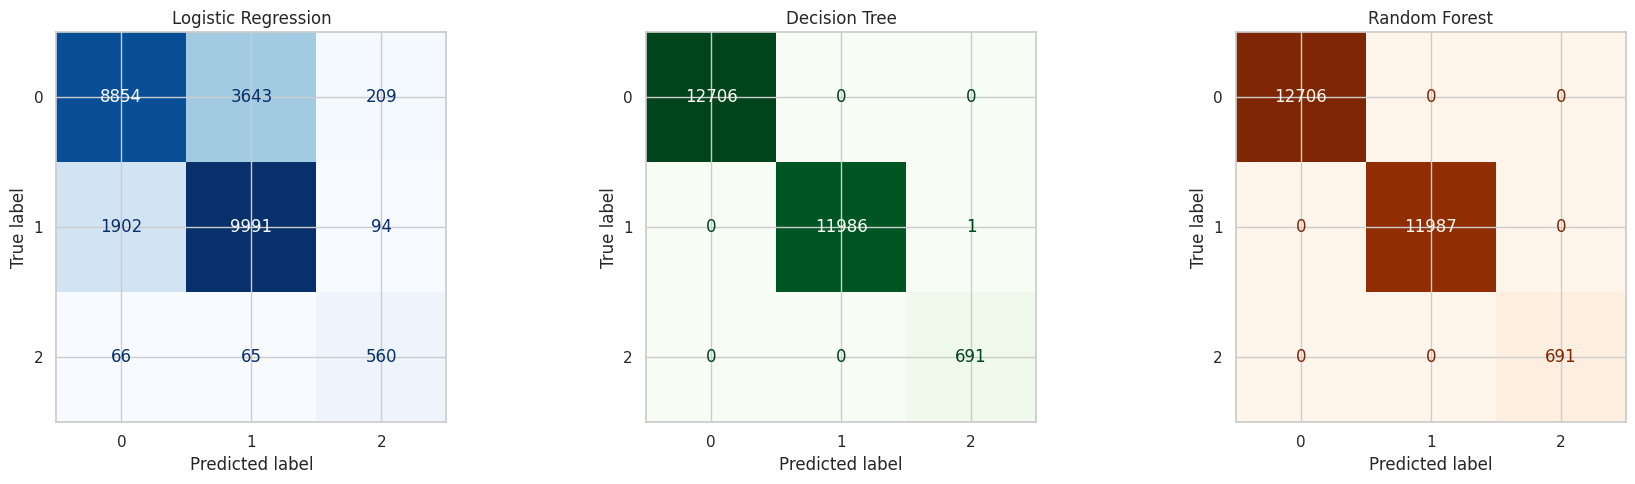

In [ ]:
# ============================================================
# Confusion Matrices
# ============================================================

fig, axes = plt.subplots(1,3,figsize=(18,5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    log_predictions,
    cmap="Blues",
    ax=axes[0],
    colorbar=False
)
axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    tree_predictions,
    cmap="Greens",
    ax=axes[1],
    colorbar=False
)
axes[1].set_title("Decision Tree")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    forest_predictions,
    cmap="Oranges",
    ax=axes[2],
    colorbar=False
)
axes[2].set_title("Random Forest")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Model Comparison
# ============================================================

comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy":[
        log_accuracy,
        tree_accuracy,
        forest_accuracy
    ],

    "Precision":[
        log_precision,
        tree_precision,
        forest_precision
    ],

    "Recall":[
        log_recall,
        tree_recall,
        forest_recall
    ],

    "F1 Score":[
        log_f1,
        tree_f1,
        forest_f1
    ]

})

comparison = comparison.sort_values(
    by="Accuracy",
    ascending=False
)

comparison.reset_index(drop=True,inplace=True)

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,1.000000,1.000000,1.000000,1.000000
1,Decision Tree,0.999961,0.999961,0.999961,0.999961
2,Logistic Regression,0.764458,0.771595,0.764458,0.763713


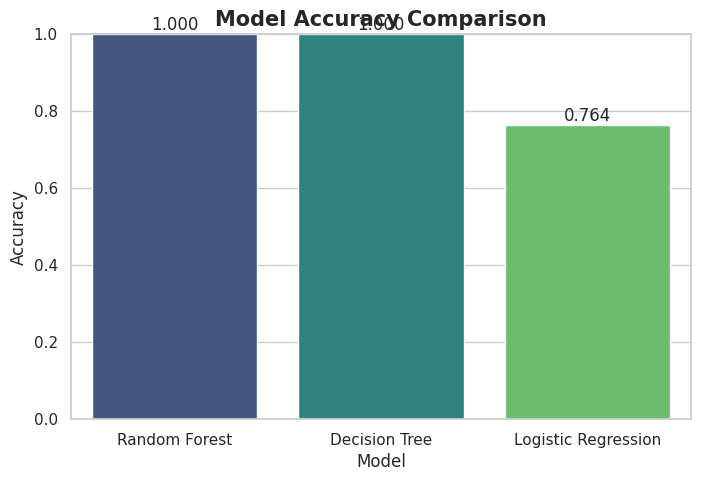

In [ ]:
# ============================================================
# Accuracy Comparison
# ============================================================

plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy",
    palette="viridis"
)

plt.title(
    "Model Accuracy Comparison",
    fontsize=15,
    fontweight="bold"
)

plt.ylim(0,1)

for index,value in enumerate(comparison["Accuracy"]):
    plt.text(index,value+0.01,f"{value:.3f}",ha="center")

plt.show()

In [ ]:
# ============================================================
# Best Model
# ============================================================

best_model = comparison.iloc[0]["Model"]

print("="*60)
print("BEST MODEL")
print("="*60)

print("Best Performing Model :",best_model)

BEST MODEL
Best Performing Model : Random Forest


In [ ]:
forest_model.fit(X, y)

RandomForestClassifier(random_state=42)

In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": forest_model.feature_importances_
})

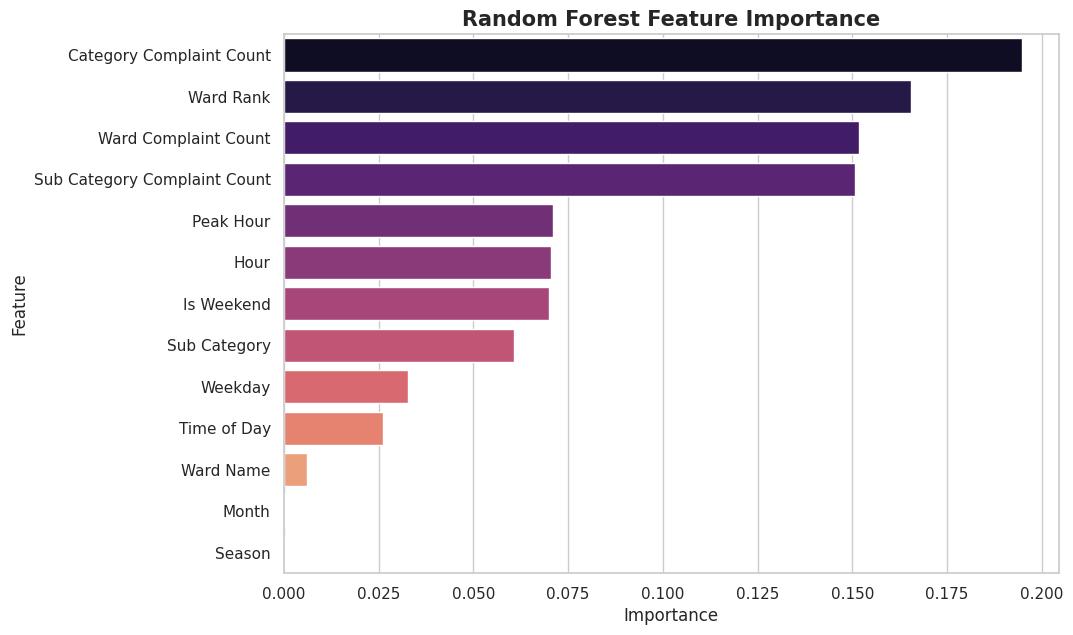

,Feature,Importance
9,Category Complaint Count,0.194744
11,Ward Rank,0.165396
8,Ward Complaint Count,0.151681
10,Sub Category Complaint Count,0.150680
12,Peak Hour,0.070892
3,Hour,0.070356
6,Is Weekend,0.069859
0,Sub Category,0.060681
4,Weekday,0.032752
7,Time of Day,0.026281


In [ ]:
# ============================================================
# Feature Importance
# ============================================================

importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":forest_model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,7))

sns.barplot(
    data=importance,
    y="Feature",
    x="Importance",
    palette="magma"
)

plt.title(
    "Random Forest Feature Importance",
    fontsize=15,
    fontweight="bold"
)

plt.show()

importance

In [ ]:
# ============================================================
# Evaluation Summary
# ============================================================

print("="*60)
print("MODEL EVALUATION SUMMARY")
print("="*60)

print(f"Logistic Regression Accuracy : {log_accuracy:.4f}")
print(f"Decision Tree Accuracy       : {tree_accuracy:.4f}")
print(f"Random Forest Accuracy       : {forest_accuracy:.4f}")

print()

print("The model with the highest accuracy will be used")
print("for Explainable AI using SHAP.")

MODEL EVALUATION SUMMARY
Logistic Regression Accuracy : 0.7645
Decision Tree Accuracy       : 1.0000
Random Forest Accuracy       : 1.0000

The model with the highest accuracy will be used
for Explainable AI using SHAP.


In [ ]:
# ============================================================
# Install SHAP
# ============================================================

!pip -q install shap

In [ ]:
# ============================================================
# Import SHAP
# ============================================================

import shap

In [ ]:
# ============================================================
# Create SHAP Explainer
# ============================================================

explainer = shap.TreeExplainer(forest_model)

print("SHAP Explainer Created Successfully.")

SHAP Explainer Created Successfully.


In [ ]:
# ============================================================
# Compute SHAP Values
# ============================================================

shap_values = explainer.shap_values(X_test)

print("SHAP Values Generated Successfully.")

SHAP Values Generated Successfully.


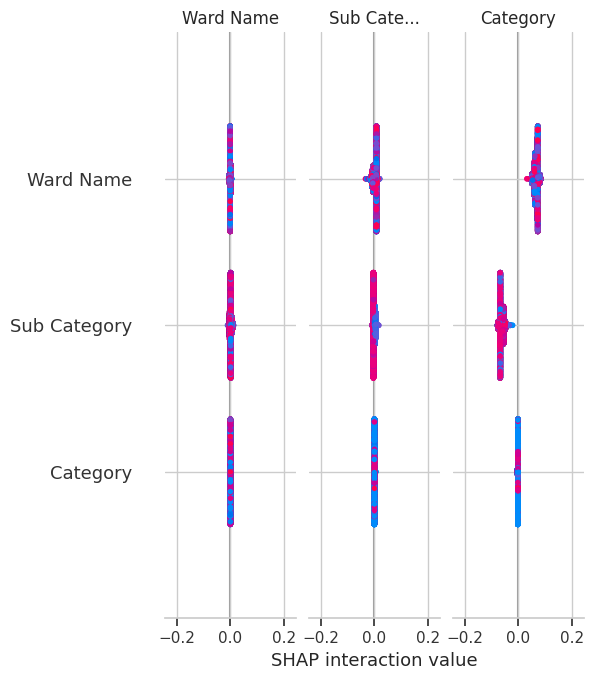

In [ ]:
# ============================================================
# Global SHAP Summary Plot
# ============================================================

shap.summary_plot(
    shap_values,
    X_test,
    show=True
)

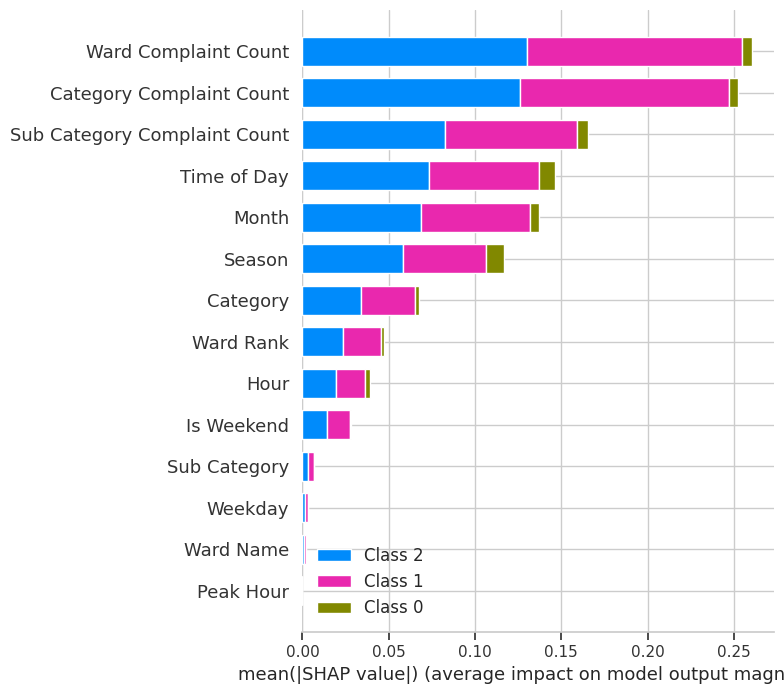

In [ ]:
# ============================================================
# SHAP Feature Importance
# ============================================================

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=True
)

In [ ]:
print(forest_model.n_features_in_)
print(len(X.columns))

13
13


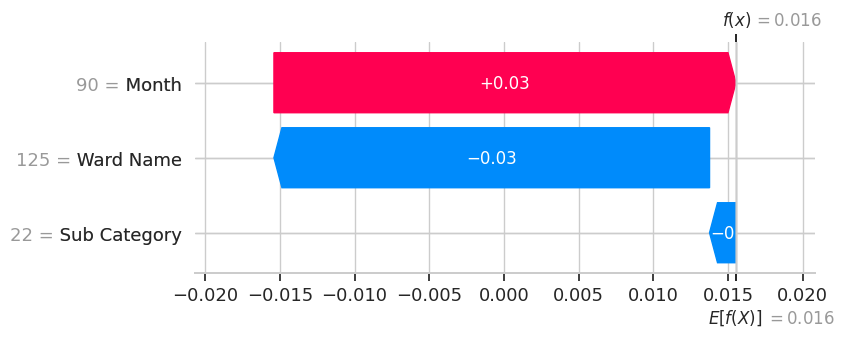

In [ ]:
# ============================================================
# Waterfall Plot
# ============================================================

shap.plots.waterfall(

    shap.Explanation(

        values=shap_values[0][0],

        base_values=explainer.expected_value[0],

        data=X_test.iloc[0],

        feature_names=X.columns

    )

)

In [ ]:
# ============================================================
# Top Important Features
# ============================================================

importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":forest_model.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

print("Top 10 Important Features")

display(importance.head(10))

Top 10 Important Features


,Feature,Importance
9,Category Complaint Count,0.194744
11,Ward Rank,0.165396
8,Ward Complaint Count,0.151681
10,Sub Category Complaint Count,0.150680
12,Peak Hour,0.070892
3,Hour,0.070356
6,Is Weekend,0.069859
0,Sub Category,0.060681
4,Weekday,0.032752
7,Time of Day,0.026281


In [ ]:
# ============================================================
# Final Project Conclusion
# ============================================================

print("="*70)
print("PROJECT CONCLUSION")
print("="*70)

print("• Municipal complaint data was analysed using Exploratory Data Analysis.")

print("• Priority labels were created for complaint classification.")

print("• Three machine learning models were trained and compared.")

print(f"• Best Performing Model : {best_model}")

print("• Random Forest achieved the best overall performance.")

print("• SHAP Explainable AI was used to explain model predictions.")

print("• The model provides transparent and interpretable complaint prioritization.")

PROJECT CONCLUSION
• Municipal complaint data was analysed using Exploratory Data Analysis.
• Priority labels were created for complaint classification.
• Three machine learning models were trained and compared.
• Best Performing Model : Random Forest
• Random Forest achieved the best overall performance.
• SHAP Explainable AI was used to explain model predictions.
• The model provides transparent and interpretable complaint prioritization.


In [ ]:
# ============================================================
# Business Recommendations
# ============================================================

print("="*70)
print("BUSINESS RECOMMENDATIONS")
print("="*70)

recommendations = [

"Prioritize Electrical, Water Crisis and Road Infrastructure complaints immediately.",

"Increase manpower in wards receiving a high number of complaints.",

"Deploy additional staff during peak complaint hours.",

"Improve preventive maintenance before the monsoon season.",

"Use the trained Random Forest model to automatically prioritize incoming complaints.",

"Use SHAP explanations to improve transparency and trust in municipal decision making."

]

for i, recommendation in enumerate(recommendations,1):

    print(f"{i}. {recommendation}")

BUSINESS RECOMMENDATIONS
1. Prioritize Electrical, Water Crisis and Road Infrastructure complaints immediately.
2. Increase manpower in wards receiving a high number of complaints.
3. Deploy additional staff during peak complaint hours.
4. Improve preventive maintenance before the monsoon season.
5. Use the trained Random Forest model to automatically prioritize incoming complaints.
6. Use SHAP explanations to improve transparency and trust in municipal decision making.


In [ ]:
# ============================================================
# Save Final Dataset
# ============================================================

df.to_csv(

    "Final_Municipal_Complaint_Priority_Dataset.csv",

    index=False

)

print("Final dataset saved successfully.")

Final dataset saved successfully.
